# Reaching system sizes up to 10000000 atoms on a single-core laptop

Because the KPM/Chebyshev expansion never diagonalizes the Hamiltonian (only sparse
matrix-vector products, whose cost per site is fixed), its cost scales *linearly* with system
size rather than the cubic scaling of exact diagonalization. Below, the same `h.get_dos(mode="KPM")`
call from the first notebook of this section is timed on sparse 1D chains from a thousand to
ten million sites, on a single core, showing the near-linear scaling that makes multi-million
atom systems tractable. The time shown is that of the KPM call alone: building the Hamiltonian
of the largest chain takes a few minutes more, and its peak memory is about 6 GB.

      1000 atoms:   0.01s


     10000 atoms:   0.06s


    100000 atoms:   0.61s


   1000000 atoms:   5.81s


   3000000 atoms:  19.93s


  10000000 atoms:  59.44s


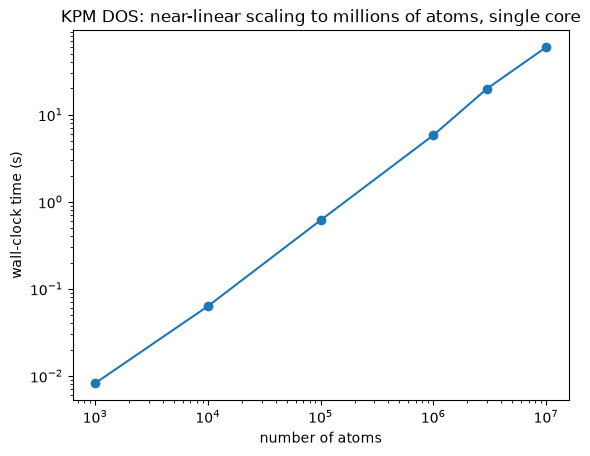

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
import time

# warm up numba's JIT compilation once, outside the timed loop below
_g0 = geometry.chain().get_supercell(100) ; _g0.dimensionality = 0
_g0.get_hamiltonian(is_sparse=True,has_spin=False).get_dos(mode="KPM",
        energies=np.linspace(-3,3,150),delta=5e-2,ntries=3)

sizes = [10**3,10**4,10**5,10**6,3*10**6,10**7]
times = []
for n in sizes:
    g = geometry.chain()
    g = g.get_supercell(n)
    g.dimensionality = 0
    h = g.get_hamiltonian(is_sparse=True,has_spin=False)
    t0 = time.time()
    x,y = h.get_dos(mode="KPM",energies=np.linspace(-3,3,150),delta=5e-2,ntries=3)
    dt = time.time()-t0
    times.append(dt)
    print(f"{n:>10d} atoms: {dt:6.2f}s")

plt.loglog(sizes,times,marker="o")
plt.xlabel("number of atoms") ; plt.ylabel("wall-clock time (s)")
plt.title("KPM DOS: near-linear scaling to millions of atoms, single core")
plt.show()

The same linear scaling makes it cheap to sweep a parameter on a large system. Below, a square
lattice of 90000 sites with Anderson disorder, an onsite energy drawn at random in $[-W/2,W/2]$ at
each site, gives a map of the density of states as a function of energy and of $W$: the van Hove
singularity at the band center is smeared out as the disorder grows, and the band edges spread
beyond $\pm 4$.

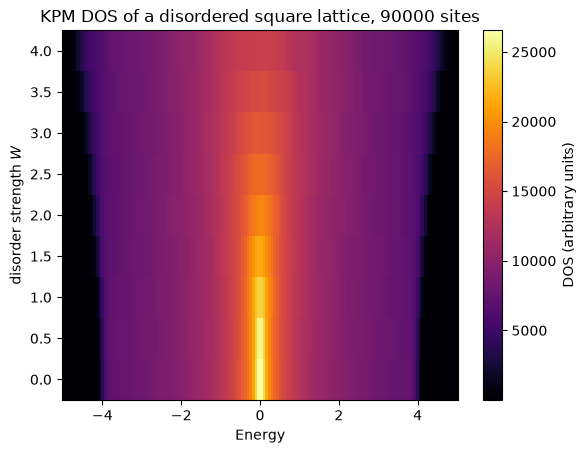

In [2]:
g = geometry.square_lattice()
g = g.get_supercell(300) # 90000 sites
g.dimensionality = 0
h0 = g.get_hamiltonian(is_sparse=True,has_spin=False)

energies = np.linspace(-5.,5.,150)
Ws = np.linspace(0.,4.,9) # disorder strengths
np.random.seed(1)
dos_map = []
for W in Ws:
    h = h0.copy()
    h.add_onsite(lambda r: W*(np.random.random()-0.5)) # Anderson disorder
    x,y = h.get_dos(mode="KPM",energies=energies,delta=5e-2,ntries=3)
    dos_map.append(y)
dos_map = np.array(dos_map)

plt.pcolormesh(energies,Ws,dos_map,cmap="inferno",shading="auto")
plt.colorbar(label="DOS (arbitrary units)")
plt.xlabel("Energy") ; plt.ylabel("disorder strength $W$")
plt.title("KPM DOS of a disordered square lattice, 90000 sites")
plt.show()